In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder



In [4]:
pip install xgboost

In [2]:
df=pd.read_csv("F.csv")
#df['type']=le.fit_transfrom(df['type'])

In [5]:
le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

In [6]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 534.0+ MB


(6362620, 11)

Data cleaning

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=['nameOrig', 'nameDest'], inplace=True)

In [10]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [11]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df.describe()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.714150e+00,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,1.350117e+00,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.000000e+00,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,1.000000e+00,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,3.000000e+00,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,4.000000e+00,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [13]:
df['type'].value_counts()

type
1    2237500
3    2151495
0    1399284
4     532909
2      41432
Name: count, dtype: int64

In [14]:
df.groupby('type')['isFraud'].sum()

type
0       0
1    4116
2       0
3       0
4    4097
Name: isFraud, dtype: int64

In [15]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [16]:
# Create a random sample for faster training.
df_sample = df.sample(n=1000000, random_state=42)

Featuers+Target

In [17]:
X = df_sample.drop(columns=['isFraud'])
y = df_sample['isFraud']

Split the data into training and testing sets.


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 Train the Random Forest model.

In [19]:
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelRF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

make predictions on test data

In [20]:
y_pred = modelRF.predict(X_test)

Evaluate the model performance

In [21]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.999665

Confusion Matrix:
 [[199746      1]
 [    66    187]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    199747
           1       0.99      0.74      0.85       253

    accuracy                           1.00    200000
   macro avg       1.00      0.87      0.92    200000
weighted avg       1.00      1.00      1.00    200000



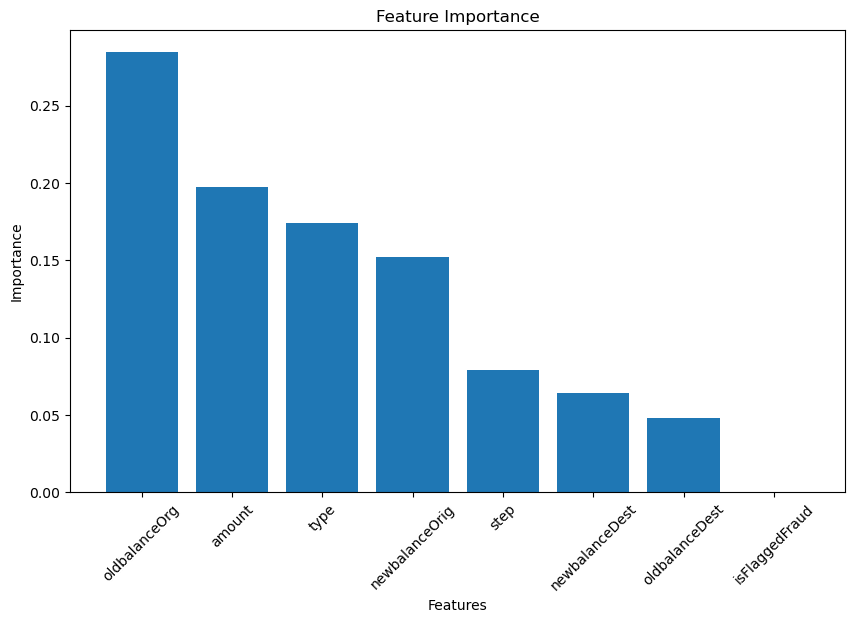

In [23]:
# Show feature importance.
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': modelRF.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

XGBOOTS

In [24]:
from xgboost import XGBClassifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [27]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
y_p = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_p))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_p))
print("\nClassification Report:\n", classification_report(y_test, y_p))

Accuracy: 0.999715

Confusion Matrix:
 [[199742      5]
 [    52    201]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    199747
           1       0.98      0.79      0.88       253

    accuracy                           1.00    200000
   macro avg       0.99      0.90      0.94    200000
weighted avg       1.00      1.00      1.00    200000



Experiment: Random Forest with SMOTE (Not Selected)
SMOTE improved Recall but significantly reduced Precision by increasing false positives.
Therefore, the baseline Random Forest model was selected.

In [54]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

EDA

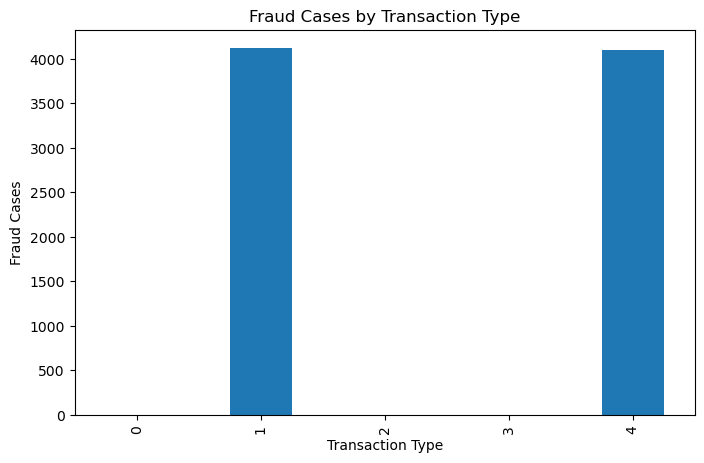

In [30]:
fraud_counts = df.groupby('type')['isFraud'].sum()

plt.figure(figsize=(8,5))
fraud_counts.plot(kind='bar')

plt.title("Fraud Cases by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Cases")
plt.show()

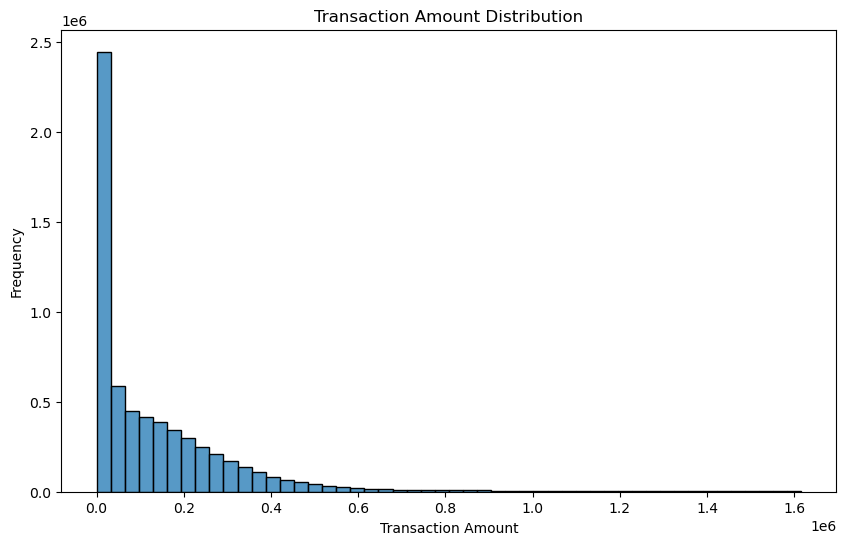

In [31]:
# Shows the distribution of transaction amounts without extreme outliers.
plt.figure(figsize=(10,6))

sns.histplot(df[df['amount'] < df['amount'].quantile(0.99)]['amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

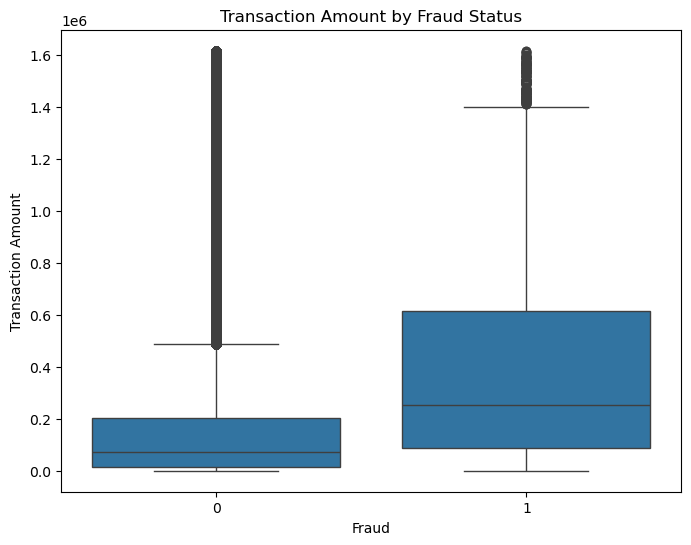

In [32]:
# Compares transaction amounts between fraudulent and normal transactions.
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df[df['amount'] < df['amount'].quantile(0.99)],
    x='isFraud',
    y='amount'
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")

plt.show()

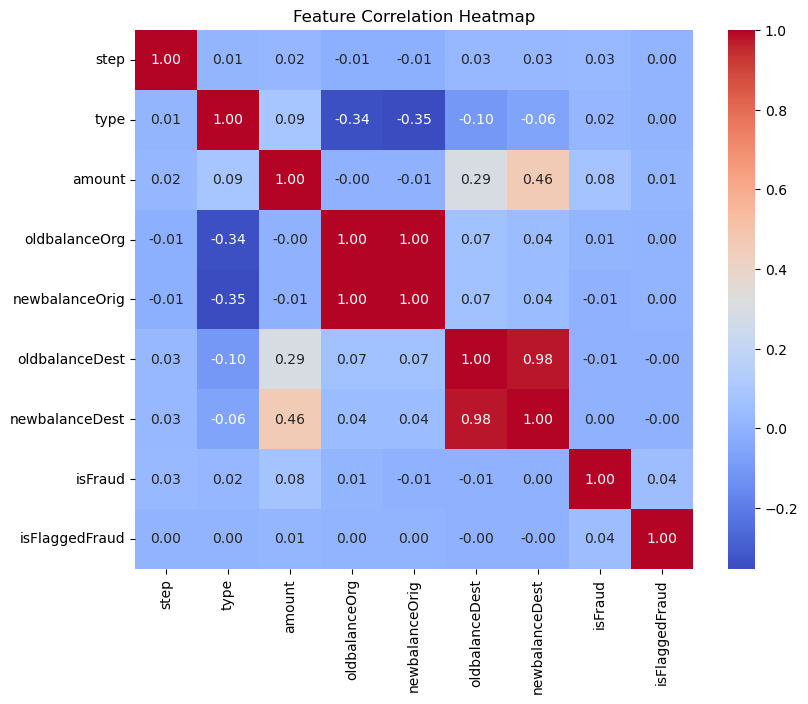

In [33]:
### Shows the correlation between numerical features.

plt.figure(figsize=(9,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

Save the Trained Model

In [90]:
import joblib

joblib.dump(model, "fraud_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [91]:
import os
print(os.path.exists("fraud_model.pkl"))
print(os.path.exists("label_encoder.pkl"))

True
True
